In [15]:
import numpy as np
import pandas as pd

study_hours = np.array([1,2,3,4,5,6,7,8,9,10,2,3,4,5,6,7,8,9]).reshape(-1,1)
passed = np.array([0,1,0,0,1,1,1,0,1,0,1,0,1,0,0,0,1,0])

df = pd.DataFrame({"Study Hours": study_hours.flatten(),"Passed": passed})
print("Dataset")
print(df)

Dataset
    Study Hours  Passed
0             1       0
1             2       1
2             3       0
3             4       0
4             5       1
5             6       1
6             7       1
7             8       0
8             9       1
9            10       0
10            2       1
11            3       0
12            4       1
13            5       0
14            6       0
15            7       0
16            8       1
17            9       0


In [16]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(study_hours, passed)
new_hours = np.array([[5.5]])

prediction = model.predict(new_hours)
probability = model.predict_proba(new_hours)
print("\nStudent Studies:", new_hours[0][0], "hours")


Student Studies: 5.5 hours


In [17]:
if prediction[0] == 1:
    print("Prediction : PASS")
else:
    print("Prediction : FAIL")

print(f"Fail Probability : {probability[0][0]*100:.2f}%")
print(f"Pass Probability : {probability[0][1]*100:.2f}%")
print(f"\nCoefficient :{model.coef_[0][0]:.3f}")
print(f"Intercept : {model.intercept_[0]:.3f}")

Prediction : FAIL
Fail Probability : 55.57%
Pass Probability : 44.43%

Coefficient :-0.032
Intercept : -0.050


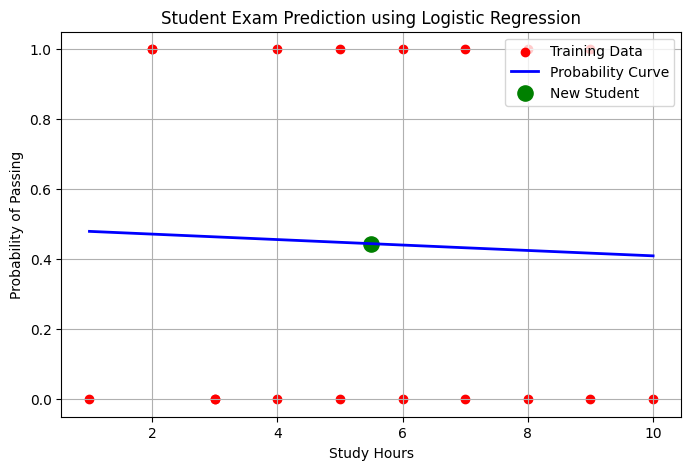

In [18]:
import matplotlib.pyplot as plt
hours = np.linspace(1,10,200).reshape(-1,1)
pass_probability = model.predict_proba(hours)[:,1]

plt.figure(figsize=(8,5))
plt.scatter(study_hours,passed,color="red",label="Training Data")
plt.plot(hours,pass_probability,color="blue",linewidth=2,label="Probability Curve")
plt.scatter(new_hours,probability[:,1],color="green",s=120,label="New Student")
plt.xlabel("Study Hours")
plt.ylabel("Probability of Passing")
plt.title("Student Exam Prediction using Logistic Regression")
plt.grid(True)
plt.legend()
plt.show()

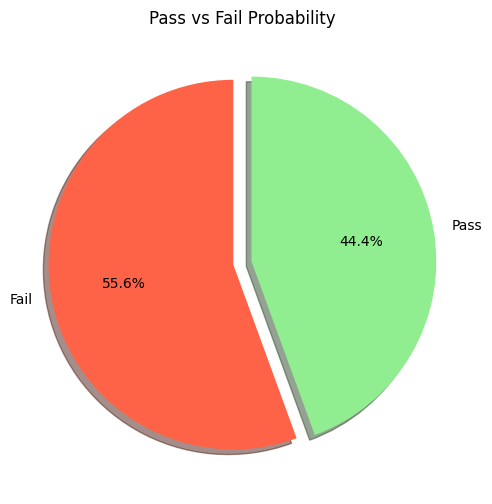

In [19]:
labels = ["Fail", "Pass"]
colors = ["tomato", "lightgreen"]

plt.figure(figsize=(6,6))
plt.pie(probability[0],labels=labels,autopct="%1.1f%%",startangle=90,explode=(0.05,0.05),
        colors=colors,shadow=True)
plt.title("Pass vs Fail Probability")
plt.show()